 Data Cleaning & Preprocessing

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('student_performance_dataset_1000.csv')
df.head()

,Student_ID,Gender,Study_Hours,Attendance_Percentage,Previous_Marks,Participation_Level,Assignment_Score,Project_Score,Test_Score,Behavior,Extracurricular_Activities,Final_Score
0,1,Male,6,88,53,Low,54,62,59,Good,No,36
1,2,Female,1,51,73,High,70,81,71,Average,Yes,40
2,3,Male,9,87,92,Medium,92,92,91,Good,Yes,54
3,4,Male,1,88,59,Medium,68,60,55,Average,Yes,35
4,5,Male,5,75,50,Medium,47,51,39,Good,No,35


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Student_ID                  1000 non-null   int64 
 1   Gender                      1000 non-null   object
 2   Study_Hours                 1000 non-null   int64 
 3   Attendance_Percentage       1000 non-null   int64 
 4   Previous_Marks              1000 non-null   int64 
 5   Participation_Level         1000 non-null   object
 6   Assignment_Score            1000 non-null   int64 
 7   Project_Score               1000 non-null   int64 
 8   Test_Score                  1000 non-null   int64 
 9   Behavior                    1000 non-null   object
 10  Extracurricular_Activities  1000 non-null   object
 11  Final_Score                 1000 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 93.9+ KB


In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 12)


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Study_Hours,0
Attendance_Percentage,0
Previous_Marks,0
Participation_Level,0
Assignment_Score,0
Project_Score,0
Test_Score,0
Behavior,0


In [ ]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


In [ ]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [ ]:
df.describe()

,Student_ID,Study_Hours,Attendance_Percentage,Previous_Marks,Assignment_Score,Project_Score,Test_Score,Final_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,5.395000,74.696000,68.167000,68.58000,70.303000,66.741000,41.350000
std,288.819436,2.912638,14.768537,16.126598,16.77155,16.867059,17.351109,5.610256
min,1.000000,1.000000,50.000000,40.000000,35.00000,35.000000,35.000000,35.000000
25%,250.750000,3.000000,62.000000,55.000000,55.00000,57.000000,53.000000,35.000000
50%,500.500000,5.000000,74.000000,68.000000,69.00000,71.000000,66.000000,41.000000
75%,750.250000,8.000000,87.250000,83.000000,82.00000,84.000000,80.000000,46.000000
max,1000.000000,10.000000,100.000000,95.000000,100.00000,100.000000,100.000000,59.000000


In [ ]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df['Participation_Level'].unique()

array(['Low', 'High', 'Medium'], dtype=object)

In [ ]:
df['Behavior'].unique()

array(['Good', 'Average', 'Poor'], dtype=object)

In [ ]:
df['Extracurricular_Activities'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df.dtypes

,0
Student_ID,int64
Gender,object
Study_Hours,int64
Attendance_Percentage,int64
Previous_Marks,int64
Participation_Level,object
Assignment_Score,int64
Project_Score,int64
Test_Score,int64
Behavior,object


In [ ]:
cleaning_summary = {
      "Total Records": len(df),
          "Total Features": len(df.columns),
              "Missing Values": df.isnull().sum().sum(),
                  "Duplicate Records": df.duplicated().sum()
                  }

print(cleaning_summary)


{'Total Records': 1000, 'Total Features': 12, 'Missing Values': np.int64(0), 'Duplicate Records': np.int64(0)}


Exploratory Data Analysis (EDA)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

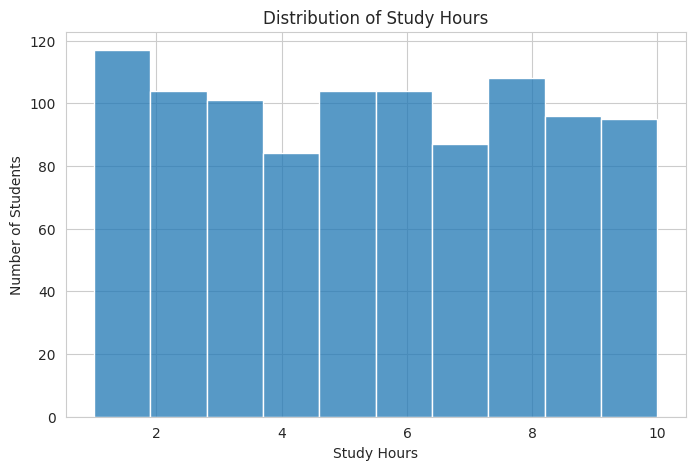

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Study_Hours'], bins=10)

plt.title('Distribution of Study Hours')
plt.xlabel('Study Hours')
plt.ylabel('Number of Students')

plt.show()

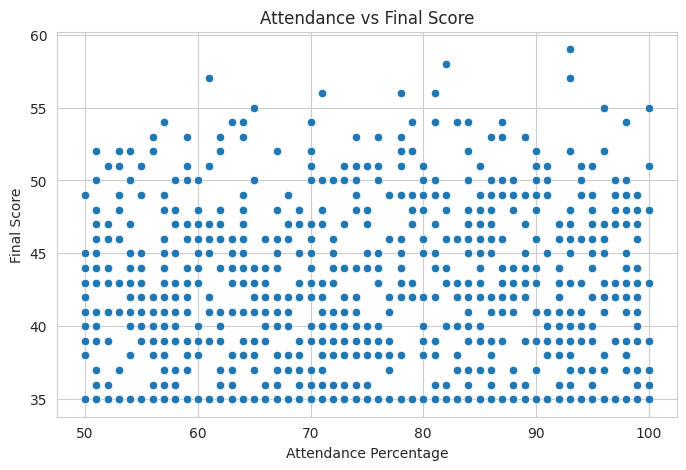

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Attendance_Percentage',
        y='Final_Score',
            data=df
            )

plt.title('Attendance vs Final Score')
plt.xlabel('Attendance Percentage')
plt.ylabel('Final Score')

plt.show()

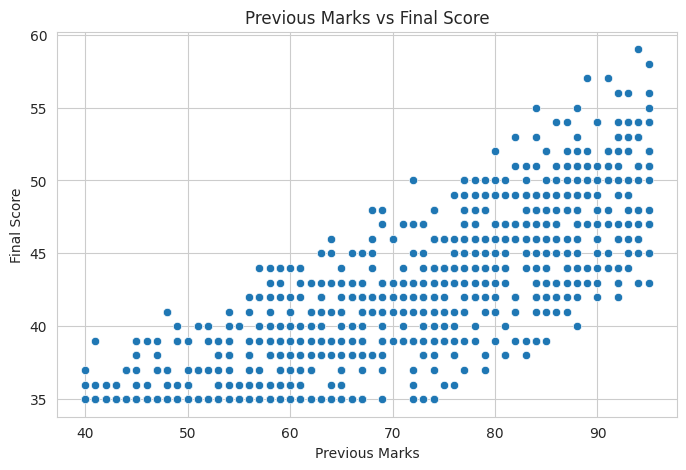

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Previous_Marks',
        y='Final_Score',
            data=df
            )

plt.title('Previous Marks vs Final Score')
plt.xlabel('Previous Marks')
plt.ylabel('Final Score')

plt.show()

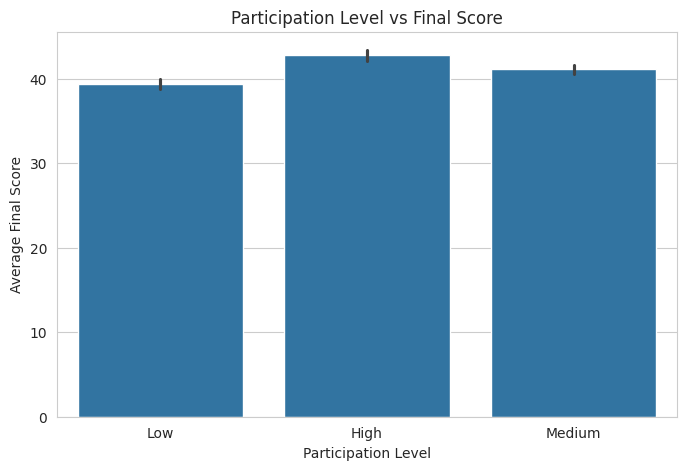

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Participation_Level',
        y='Final_Score',
            data=df
            )

plt.title('Participation Level vs Final Score')
plt.xlabel('Participation Level')
plt.ylabel('Average Final Score')

plt.show()

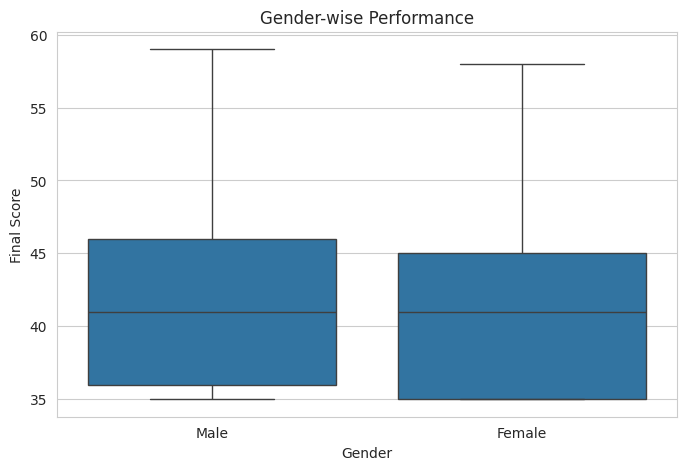

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Gender',
        y='Final_Score',
            data=df
            )

plt.title('Gender-wise Performance')
plt.xlabel('Gender')
plt.ylabel('Final Score')

plt.show()

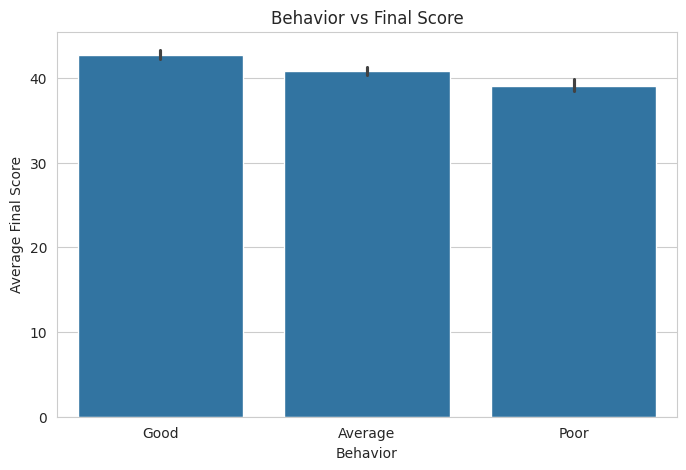

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Behavior',
        y='Final_Score',
            data=df
            )

plt.title('Behavior vs Final Score')
plt.xlabel('Behavior')
plt.ylabel('Average Final Score')

plt.show()

In [ ]:
df_encoded = df.copy()

df_encoded['Gender'] = df_encoded['Gender'].map({'Male':0,'Female':1})
df_encoded['Participation_Level'] = df_encoded['Participation_Level'].map({'Low':1,'Medium':2,'High':3})
df_encoded['Behavior'] = df_encoded['Behavior'].map({'Poor':1,'Average':2,'Good':3})
df_encoded['Extracurricular_Activities'] = df_encoded['Extracurricular_Activities'].map({'No':0,'Yes':1})

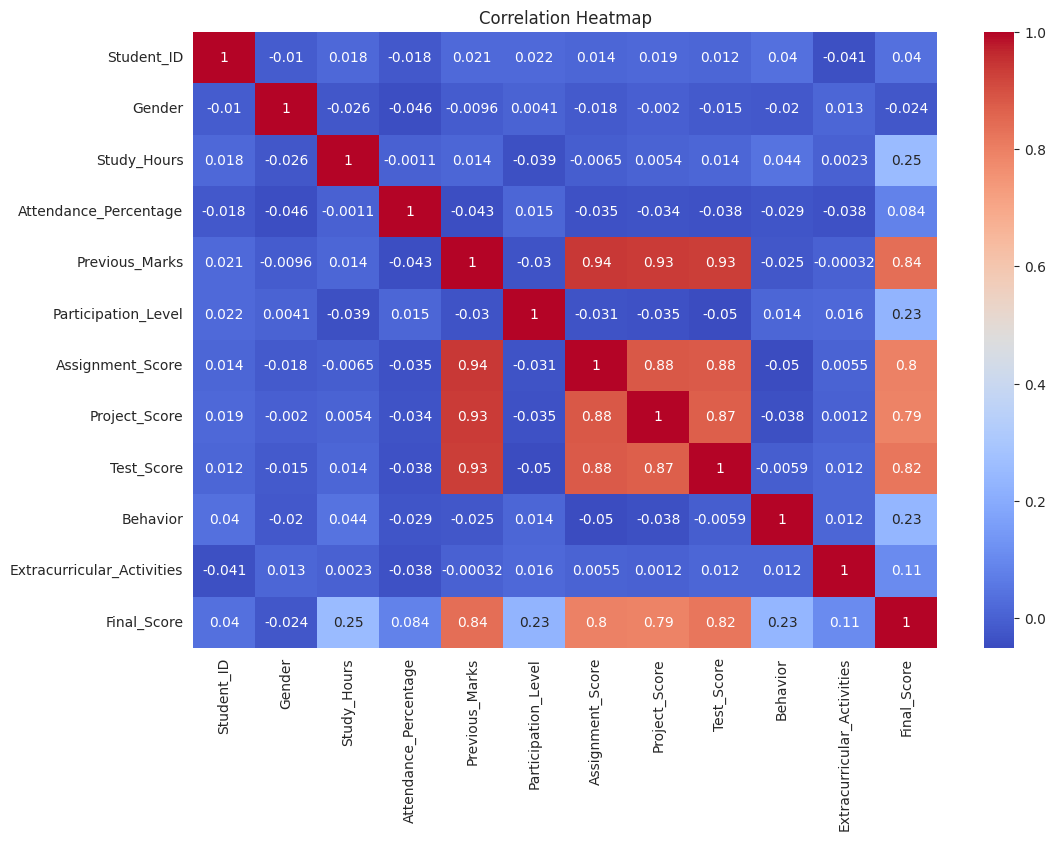

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
        annot=True,
            cmap='coolwarm'
            )

plt.title('Correlation Heatmap')

plt.show()

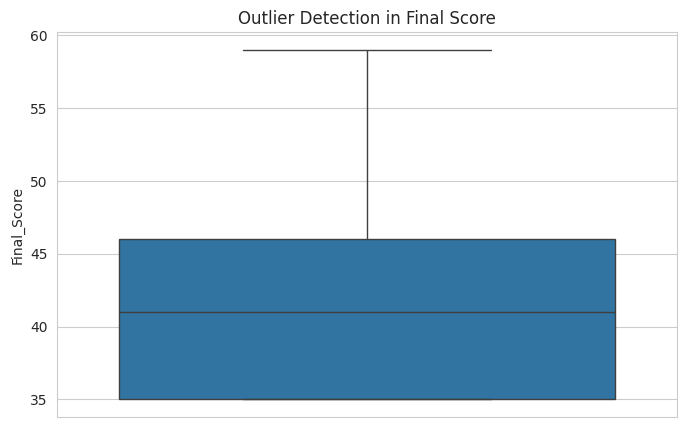

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y='Final_Score',
        data=df
        )

plt.title('Outlier Detection in Final Score')

plt.show()

Feature Engineering & Data Preparation

Create Performance Category

In [ ]:
def performance_level(score):
      if score < 60:
              return 'Low'
      elif score < 80:
                          return 'Medium'
      else:
                                      return 'High'

df['Performance_Level'] = df['Final_Score'].apply(performance_level)

df[['Final_Score','Performance_Level']].head()

,Final_Score,Performance_Level
0,36,Low
1,40,Low
2,54,Low
3,35,Low
4,35,Low


In [ ]:
df['Performance_Level'].value_counts()

,count
Performance_Level,
Low,1000


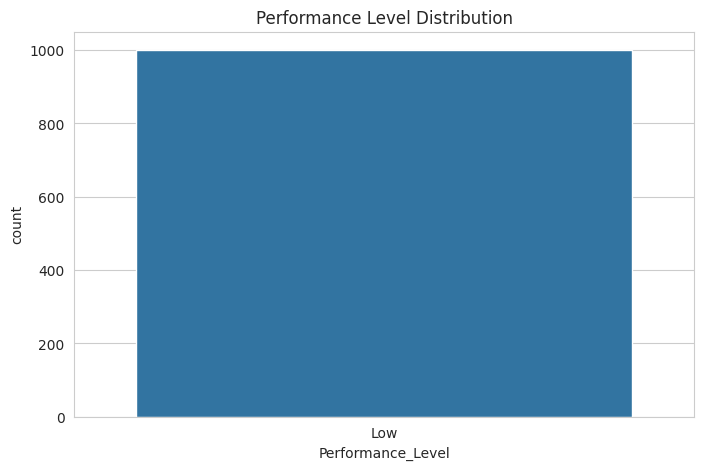

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    x='Performance_Level',
        data=df
        )

plt.title("Performance Level Distribution")

plt.show()

In [ ]:
df_encoded = df.copy()

df_encoded['Gender'] = df_encoded['Gender'].map({
    'Male':0,
        'Female':1
        })

df_encoded['Participation_Level'] = df_encoded['Participation_Level'].map({
            'Low':1,
                'Medium':2,
                    'High':3
                    })

df_encoded['Behavior'] = df_encoded['Behavior'].map({
                        'Poor':1,
                            'Average':2,
                                'Good':3
                                })

df_encoded['Extracurricular_Activities'] = df_encoded['Extracurricular_Activities'].map({
                                    'No':0,
                                        'Yes':1
                                        })

In [ ]:
df_encoded.head()

,Student_ID,Gender,Study_Hours,Attendance_Percentage,Previous_Marks,Participation_Level,Assignment_Score,Project_Score,Test_Score,Behavior,Extracurricular_Activities,Final_Score,Performance_Level
0,1,0,6,88,53,1,54,62,59,3,0,36,Low
1,2,1,1,51,73,3,70,81,71,2,1,40,Low
2,3,0,9,87,92,2,92,92,91,3,1,54,Low
3,4,0,1,88,59,2,68,60,55,2,1,35,Low
4,5,0,5,75,50,2,47,51,39,3,0,35,Low


In [ ]:
features = [
      'Gender',
          'Study_Hours',
              'Attendance_Percentage',
                  'Previous_Marks',
                      'Participation_Level',
                          'Assignment_Score',
                              'Project_Score',
                                  'Test_Score',
                                      'Behavior',
                                          'Extracurricular_Activities'
                                          ]


In [ ]:
target = 'Final_Score'

In [ ]:
X = df_encoded[features]

y = df_encoded[target]

In [ ]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1000, 10)
y Shape: (1000,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
        y,
            test_size=0.20,
                random_state=42
                )

In [ ]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 10)
Testing Data: (200, 10)


 Model Building & Training
 We will train 4 models and compare them.



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
        mean_squared_error,
            r2_score
            )

import numpy as np

Linear Regression

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression
MAE: 1.195984893350511
RMSE: 1.4697166839284777
R2 Score: 0.9361486056288658


Linear Regression
Linear Regression established a baseline model and showed a strong relationship between input features and student performance.

Decision Tree Regressor

In [ ]:
dt = DecisionTreeRegressor(
      random_state=42
      )

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)


In [ ]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree
MAE: 1.745
RMSE: 2.5406692031825
R2 Score: 0.8091907678482748


Decision Tree
Decision Tree captured non-linear relationships and improved prediction accuracy compared to basic regression.

Random Forest Regressor

In [ ]:
rf = RandomForestRegressor(
      n_estimators=100,
          random_state=42
          )

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest
MAE: 1.00945
RMSE: 1.3267386705753321
R2 Score: 0.9479675934684418


Random Forest
Random Forest achieved the highest prediction accuracy due to its ensemble learning capability and ability to reduce overfitting.

 Support Vector Regressor

In [ ]:
svr = SVR()

svr.fit(X_train, y_train)

y_pred_svr = svr.predict(X_test)

In [ ]:
mae_svr = mean_absolute_error(y_test, y_pred_svr)

rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

r2_svr = r2_score(y_test, y_pred_svr)

print("SVR")
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)
print("R2 Score:", r2_svr)

SVR
MAE: 2.1145127754654003
RMSE: 2.7435723144205433
R2 Score: 0.7774969540149781


SVR
Support Vector Regressor provided reasonable predictions but required more tuning for optimal performance.

Create Comparison Table

In [ ]:
results = {
      'Model': [
              'Linear Regression',
                      'Decision Tree',
                              'Random Forest',
                                      'SVR'
                                          ],
                                              'MAE': [
                                                      mae_lr,
                                                              mae_dt,
                                                                      mae_rf,
                                                                              mae_svr
                                                                                  ],
                                                                                      'RMSE': [
                                                                                              rmse_lr,
                                                                                                      rmse_dt,
                                                                                                              rmse_rf,
                                                                                                                      rmse_svr
                                                                                                                          ],
                                                                                                                              'R2 Score': [
                                                                                                                                      r2_lr,
                                                                                                                                              r2_dt,
                                                                                                                                                      r2_rf,
                                                                                                                                                              r2_svr
                                                                                                                                                                  ]
                                                                                                                                                                  }

results_df = pd.DataFrame(results)

results_df


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.195985,1.469717,0.936149
1,Decision Tree,1.745000,2.540669,0.809191
2,Random Forest,1.009450,1.326739,0.947968
3,SVR,2.114513,2.743572,0.777497


Find Best Model

In [ ]:
best_model = results_df.loc[
      results_df['R2 Score'].idxmax()
      ]

print(best_model)


Model       Random Forest
MAE               1.00945
RMSE             1.326739
R2 Score         0.947968
Name: 2, dtype: object


Final Insight
Random Forest Regressor was selected as the best-performing model because it achieved the highest R² score and lowest prediction error among all models.

Create Model Comparison Chart

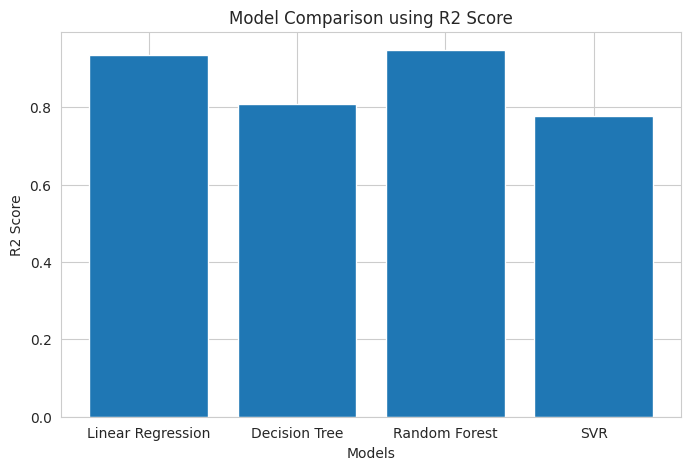

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
        results_df['R2 Score']
        )

plt.title('Model Comparison using R2 Score')

plt.xlabel('Models')

plt.ylabel('R2 Score')

plt.show()

Model Evaluation & Results Analysis

 Actual vs Predicted (Best Model)
 Assuming Random Forest is the best model:

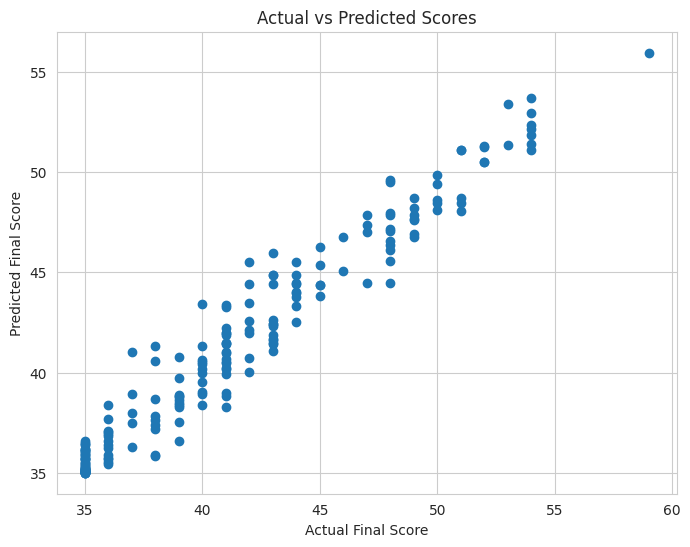

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Scores")

plt.show()

Insight
The predicted scores closely follow the actual scores, indicating good model performance.

Feature Importance
Random Forest can show which features matter most.

In [ ]:
feature_importance = pd.DataFrame({
      'Feature': X.columns,
          'Importance': rf.feature_importances_
          })

feature_importance = feature_importance.sort_values(
              by='Importance',
                  ascending=False
                  )

feature_importance


,Feature,Importance
3,Previous_Marks,0.594844
7,Test_Score,0.145797
1,Study_Hours,0.067523
4,Participation_Level,0.057636
8,Behavior,0.056944
6,Project_Score,0.025602
2,Attendance_Percentage,0.022581
5,Assignment_Score,0.020171
9,Extracurricular_Activities,0.006377
0,Gender,0.002524


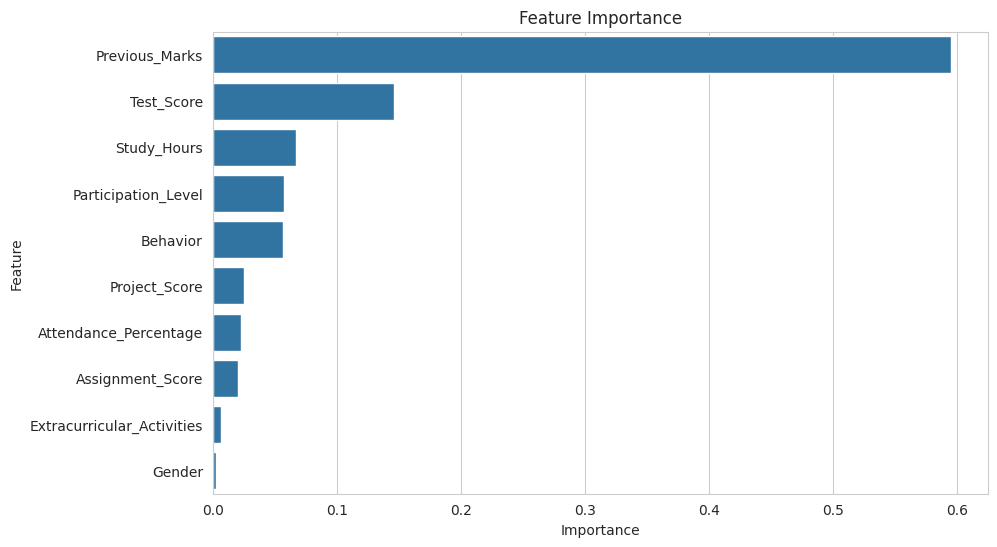

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
        y='Feature',
            data=feature_importance
            )

plt.title("Feature Importance")

plt.show()

Insight
Features such as Previous Marks, Study Hours, Attendance Percentage, and Test Score contribute most to predicting student performance.

Residual Plot

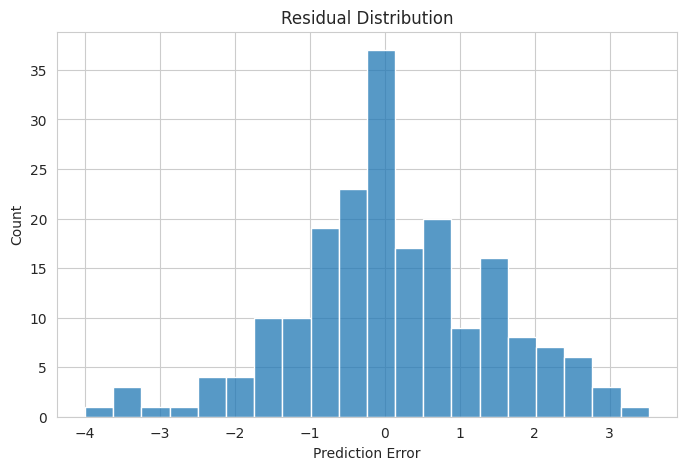

In [ ]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=20)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")

plt.show()

Insight
Errors are concentrated around zero, indicating that predictions are generally accurate.

 Model Performance Summary Table

In [ ]:
results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.195985,1.469717,0.936149
1,Decision Tree,1.745000,2.540669,0.809191
2,Random Forest,1.009450,1.326739,0.947968
3,SVR,2.114513,2.743572,0.777497


In [ ]:
best_model = results_df.loc[
      results_df['R2 Score'].idxmax()
      ]

best_model


,2
Model,Random Forest
MAE,1.00945
RMSE,1.326739
R2 Score,0.947968


Insight
Random Forest Regressor achieved the highest R² score and was selected as the final model.

